# Student-t vs Gaussian State Noise in the 1D Particle Filter

**Part 4 of a supervised research project — Dr Mathieu Gerber, University of Bristol**

## The question

> *"In your 1D study, apply the particle filter as if $v_t$ is a student t random variable and
> compare the result with those you get when the PF is applied with $v_t$ Gaussian. If the
> observations are unbounded, PF with student distribution should be more unstable than the one
> with the normal distribution. To generate the observations, you can for instance sample from your
> model with $a = 1$."*

## The setup

The **data** are generated exactly as in Part 1 — an ordinary linear-Gaussian model with $a = 1$:

$$x_t = b\,x_{t-1} + v_t,\quad v_t \sim \mathcal{N}(0, Q), \qquad y_t = a\,x_t + e_t,\quad e_t \sim \mathcal{N}(0, R)$$

with $b = 0.9$, $a = 1$, $Q = 1$, $R = 1$. What changes is the **filter**. One particle filter
propagates its particles with Gaussian noise, matching the data. The other propagates them with
**Student-t** noise:

$$v_t = s\,T_\nu, \qquad T_\nu \sim \text{Student-t}(\nu)$$

Everything else — the weighting by the Gaussian observation likelihood, the ESS-triggered
resampling at $N/2$ — is unchanged. The single difference is one line: how particles move.

The Student-t has **heavy tails**. Where a Gaussian essentially never produces a jump of size 10, a
Student-t does so regularly. The parameter $\nu$ (degrees of freedom) controls how heavy: small
$\nu$ is very heavy-tailed, and as $\nu \to \infty$ the Student-t becomes the Gaussian exactly. So
the Gaussian filter is the $\nu = \infty$ end of the same family, which makes the comparison clean.

## The benchmark problem, and how it is solved

Parts 1–3 could measure the particle filter's error exactly, because the Kalman filter gives the
exact posterior for a linear-Gaussian model. **That no longer works here.** The Student-t filter is
not a linear-Gaussian model, so the Kalman filter is not its exact answer, and comparing the
Student-t particle filter to the Kalman filter would confuse two completely different things:

1. **Approximation error** — the particle filter failing to represent its own target. *This is what
   "unstable" refers to.*
2. **Model error** — the Student-t model's own posterior being different from the Gaussian one,
   which would happen even with infinitely many particles.

To separate them this notebook adds a **grid filter**: a deterministic numerical filter that
computes the exact filtering distribution of *either* model on a fine grid, with no Monte Carlo
noise at all. Each particle filter is then measured against the exact filter **of its own model**,
which isolates (1) from (2). Section 1 verifies that the grid filter reproduces the Kalman filter to
machine precision, so the new benchmark is trustworthy.

## Roadmap

| Section | Content |
|---|---|
| 1 | Setup and verification of the new machinery |
| 2 | What actually changes when $v_t$ becomes Student-t |
| 3 | The comparison as asked: ordinary data from the model |
| 4 | Why nothing happened in Section 3 |
| 5 | Pushing the observations: the unbounded regime |
| 6 | The likelihood estimate — the sharpest diagnostic |
| 7 | Why the answer is not monotonic in $\nu$ |
| 8 | Verdict, and questions for the meeting |

*Nothing in Parts 1–3 was edited. All new code lives in `student_t_filters.py`, which imports the
shared pieces from `filters.py`.*

---
### Setup

In [1]:
import math, warnings
import numpy as np
import matplotlib.pyplot as plt

from filters import simulate_data, kalman_filter, particle_filter
from student_t_filters import (noise_scale, transition_logpdf,
                               particle_filter_noise, grid_filter)

B, A, Q, R = 0.9, 1.0, 1.0, 1.0      # same model as Part 1
DATA_SEED  = 42
N_PART     = 1000

plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
# One colour per filter, used consistently throughout.
COL = {"Gaussian": "tab:blue", "t nu=5": "tab:orange",
       "t nu=3": "tab:red", "t nu=1": "tab:purple"}

# Known-spurious NumPy 2.0 + Apple Accelerate warnings (see Parts 2-3), plus the
# log(0) that arises when a particle weight underflows to exactly zero -- that is
# intended (an impossible particle has log-weight -inf) and is handled correctly
# by the log-sum-exp shift.
warnings.filterwarnings("ignore", message=".*encountered in matmul")
warnings.filterwarnings("ignore", message=".*divide by zero encountered in log")

print(f"model: b={B}, a={A}, Q={Q}, R={R} | data seed {DATA_SEED} | N={N_PART}")

model: b=0.9, a=1.0, Q=1.0, R=1.0 | data seed 42 | N=1000


---
## Section 1 — Setup and verification

Two new pieces of machinery are introduced in this notebook, and both have to be trusted before any
result means anything:

1. **A particle filter that can use Student-t state noise** (`particle_filter_noise`). It must be
   identical to Part 1's filter when the noise is Gaussian — otherwise differences later could just
   be a rewriting bug.
2. **A grid filter** (`grid_filter`) — the new exact benchmark. It discretises the state space
   finely and carries out the filtering recursion numerically:
   $$p(x_t \mid y_{0:t-1}) = \sum_k f(x_t - b\,x_k)\,p(x_k \mid y_{0:t-1})\,h, \qquad
     p(x_t \mid y_{0:t}) \propto g(y_t \mid x_t)\,p(x_t \mid y_{0:t-1})$$
   where $f$ is the density of $v_t$ and $g$ the observation density. With a fine enough grid this
   is exact for practical purposes, and unlike the Kalman filter it works for **any** $f$.

Four checks follow. Each one is designed so that a plausible bug would break it.

In [2]:
x_true, y_obs = simulate_data(T=100, b=B, a=A, Q=Q, R=R, seed=DATA_SEED)

print("CHECK 1 -- the new filter reproduces Part 1 exactly when the noise is Gaussian")
e_old, s_old, r_old = particle_filter(y_obs, N=N_PART, seed=DATA_SEED)
e_new, s_new, r_new, _ = particle_filter_noise(y_obs, N=N_PART, seed=DATA_SEED, noise="gaussian")
print(f"   max|estimate difference| = {np.abs(e_old-e_new).max():.2e}")
print(f"   max|ESS difference|      = {np.abs(s_old-s_new).max():.2e}")
print(f"   identical resampling steps: {np.array_equal(r_old, r_new)}")

print("\nCHECK 2 -- the grid filter reproduces the Kalman filter (the Part 1 benchmark)")
m_kf, P_kf = kalman_filter(y_obs, b=B, a=A, Q=Q, R=R, P0=0.0)
for h in (0.05, 0.02):
    m_g, v_g, _ = grid_filter(y_obs, b=B, a=A, Q=Q, R=R, noise="gaussian", h=h)
    print(f"   h={h}: max|mean diff| = {np.abs(m_g-m_kf).max():.2e}, "
          f"max|variance diff| = {np.abs(v_g-P_kf).max():.2e}")

print("\nCHECK 3 -- Student-t collapses onto the Gaussian as nu grows (same family)")
m_gauss, _, _ = grid_filter(y_obs, b=B, a=A, Q=Q, R=R, noise="gaussian")
for nu in (10, 1000, 10**7):
    m_t, _, _ = grid_filter(y_obs, b=B, a=A, Q=Q, R=R, noise="student_t", nu=nu)
    print(f"   nu={nu:>9}: max|mean diff from Gaussian| = {np.abs(m_t-m_gauss).max():.2e}")

CHECK 1 -- the new filter reproduces Part 1 exactly when the noise is Gaussian
   max|estimate difference| = 0.00e+00
   max|ESS difference|      = 0.00e+00
   identical resampling steps: True

CHECK 2 -- the grid filter reproduces the Kalman filter (the Part 1 benchmark)
   h=0.05: max|mean diff| = 8.88e-16, max|variance diff| = 7.22e-15
   h=0.02: max|mean diff| = 8.88e-16, max|variance diff| = 5.44e-15

CHECK 3 -- Student-t collapses onto the Gaussian as nu grows (same family)


   nu=       10: max|mean diff from Gaussian| = 3.82e-01
   nu=     1000: max|mean diff from Gaussian| = 3.66e-03
   nu= 10000000: max|mean diff from Gaussian| = 3.65e-07


CHECK 4 -- each particle filter converges to the exact filter OF ITS OWN MODEL at O(1/sqrt(N))


   Gaussian : N=50:0.1334  N=200:0.0616  N=1000:0.0252  N=5000:0.0115  N=20000:0.0057   slope -0.526


   t nu=3   : N=50:0.1318  N=200:0.0600  N=1000:0.0272  N=5000:0.0125  N=20000:0.0059   slope -0.511


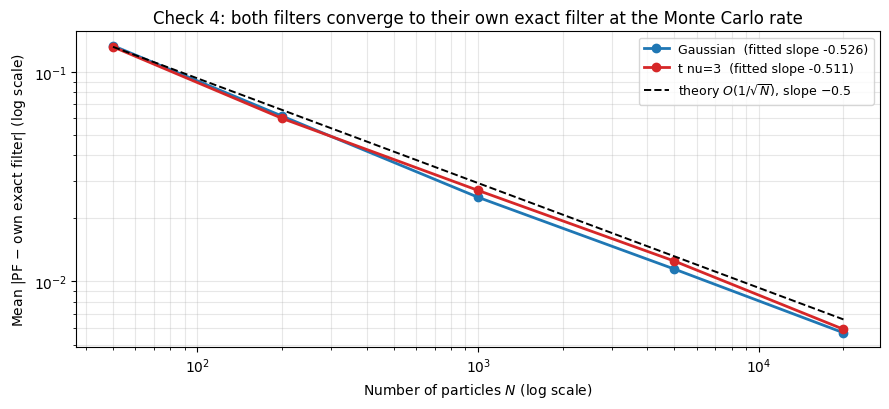

In [3]:
print("CHECK 4 -- each particle filter converges to the exact filter OF ITS OWN MODEL at O(1/sqrt(N))")
fig, ax = plt.subplots(figsize=(9, 4.2))
for name, noise, nu in (("Gaussian", "gaussian", None), ("t nu=3", "student_t", 3)):
    exact, _, _ = grid_filter(y_obs, b=B, a=A, Q=Q, R=R, noise=noise, nu=nu)
    Ns = [50, 200, 1000, 5000, 20000]
    errs = [np.mean([np.abs(particle_filter_noise(y_obs, N=n, seed=k, b=B, a=A, Q=Q, R=R,
                                                  noise=noise, nu=nu)[0] - exact).mean()
                     for k in range(8)]) for n in Ns]
    slope = np.polyfit(np.log(Ns), np.log(errs), 1)[0]
    ax.loglog(Ns, errs, "o-", color=COL[name], lw=2, ms=6,
              label=f"{name}  (fitted slope {slope:.3f})")
    print(f"   {name:9s}: " + "  ".join(f"N={n}:{e:.4f}" for n, e in zip(Ns, errs))
          + f"   slope {slope:.3f}")
ref = np.array(errs[0]) * np.sqrt(Ns[0] / np.array(Ns, dtype=float))
ax.loglog(Ns, ref, "k--", lw=1.4, label="theory $O(1/\\sqrt{N})$, slope $-0.5$")
ax.set_title("Check 4: both filters converge to their own exact filter at the Monte Carlo rate")
ax.set_xlabel("Number of particles $N$ (log scale)")
ax.set_ylabel("Mean $|$PF $-$ own exact filter$|$ (log scale)")
ax.legend(fontsize=9); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

**Conclusion.** All four checks pass. The Gaussian path reproduces Part 1 **bit for bit**, including
which steps triggered resampling, so nothing was broken in the rewrite. The grid filter matches the
Kalman filter to about $10^{-15}$, so the new benchmark is exact for practical purposes. The
Student-t model collapses onto the Gaussian as $\nu$ grows, confirming they are one family. And each
particle filter converges to the exact filter of its own model at the $O(1/\sqrt{N})$ rate. The
machinery is trustworthy.

---
## Section 2 — What actually changes when $v_t$ is Student-t

Before running any filter it is worth seeing what the change does, because the whole question turns
on it.

The Gaussian and the Student-t look almost identical in the middle. The difference is entirely in
the **tails** — how plausible the model thinks a very large jump is. A Gaussian log-density falls
like $-v^2$, so large jumps are astronomically unlikely. A Student-t log-density falls only like
$-(\nu+1)\log|v|$, so large jumps stay merely unlikely.

**A note on scale.** There are two fair ways to set the scale $s$:

- **Scale-matched** ($s = \sqrt{Q}$): the direct reading of "replace the Gaussian by a Student-t".
  As $\nu \to \infty$ it recovers $\mathcal{N}(0, Q)$ exactly. But for small $\nu$ the Student-t's
  *variance* is then larger than $Q$ (infinite for $\nu \le 2$).
- **Variance-matched** ($s = \sqrt{Q(\nu-2)/\nu}$, needs $\nu > 2$): the variance is exactly $Q$, so
  the only difference from the Gaussian is the **shape** of the tails.

Scale-matching is used by default, and the variance-matched version is run later as a control — so
that "the Student-t is simply wider" can be ruled out as the explanation of anything we find.

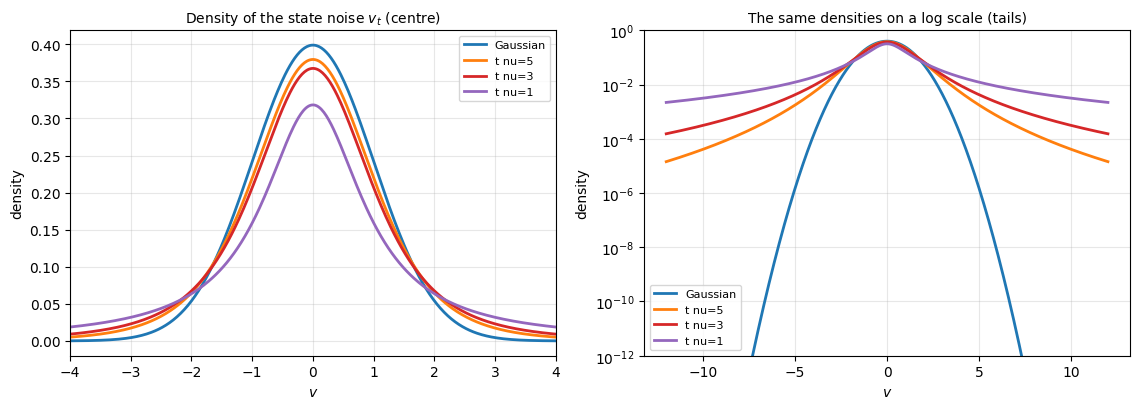

How often does each model think a jump of size >= J happens?  P(|v| >= J)

   J     Gaussian       t nu=5       t nu=3       t nu=1


   2     4.55e-02     1.02e-01     1.39e-01     2.95e-01
   5     2.50e-07     4.04e-03     1.55e-02     1.26e-01
  10     0.00e+00     1.65e-04     2.15e-03     6.35e-02
  20     0.00e+00     3.50e-06     2.58e-04     3.18e-02
  50     0.00e+00     0.00e+00     2.00e-05     1.27e-02

A jump of 20 is a 1-in-10^88 event for the Gaussian and a 1-in-63 event for the Cauchy.


In [4]:
v = np.linspace(-12, 12, 1201)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.2))

for name, nu in (("Gaussian", None), ("t nu=5", 5), ("t nu=3", 3), ("t nu=1", 1)):
    noise = "gaussian" if nu is None else "student_t"
    dens = np.exp(transition_logpdf(v, noise, nu, noise_scale(Q, nu, "scale")))
    a1.plot(v, dens, color=COL[name], lw=2, label=name)
    a2.semilogy(v, dens, color=COL[name], lw=2, label=name)
a1.set_xlim(-4, 4); a1.set_title("Density of the state noise $v_t$ (centre)", fontsize=10)
a2.set_ylim(1e-12, 1); a2.set_title("The same densities on a log scale (tails)", fontsize=10)
for ax in (a1, a2):
    ax.set_xlabel("$v$"); ax.set_ylabel("density"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("How often does each model think a jump of size >= J happens?  P(|v| >= J)\n")
print(f"{'J':>4}" + "".join(f"{n:>13}" for n in ("Gaussian", "t nu=5", "t nu=3", "t nu=1")))
rng = np.random.default_rng(0)
big = {"Gaussian": rng.standard_normal(4_000_000)}
for nu in (5, 3, 1):
    big[f"t nu={nu}"] = rng.standard_t(nu, size=4_000_000)
for J in (2, 5, 10, 20, 50):
    print(f"{J:>4}" + "".join(f"{np.mean(np.abs(big[n]) >= J):>13.2e}"
                              for n in ("Gaussian", "t nu=5", "t nu=3", "t nu=1")))
print("\nA jump of 20 is a 1-in-10^88 event for the Gaussian and a 1-in-63 event for the Cauchy.")

**Conclusion.** The two noise models are nearly indistinguishable near the centre and wildly
different far out: a jump of size 20 has probability about $3\times10^{-2}$ — roughly 1 in 31 — under
the Cauchy ($\nu = 1$), while under the Gaussian it is around $10^{-88}$, so small that four million
samples record it as exactly zero. Since the particle filter moves its particles by drawing this
noise, the Student-t filter scatters a few particles very far out at every step — that is the entire
mechanism at work in the rest of this notebook.

---
## Section 3 — The comparison as asked: ordinary data from the model

This is the experiment exactly as instructed: generate observations from the model with $a = 1$, run
the particle filter with Gaussian $v_t$ and with Student-t $v_t$, and compare.

Each filter is scored against the exact filter of its own model, so what is measured is purely
approximation error. Alongside it the table reports **model error** (`misspec`) — how far the
Student-t model's *exact* posterior sits from the Kalman filter's — which is a property of the model
and has nothing to do with particles. Keeping these apart matters: a Student-t filter can look
"wrong" relative to the Kalman filter purely because it is answering a different question.

We run to $T = 2000$ with $N = 1000$, averaging over 10 particle-filter seeds.

In [5]:
T_MAIN, N_SEEDS = 2000, 10
x_long, y_long = simulate_data(T=T_MAIN, b=B, a=A, Q=Q, R=R, seed=DATA_SEED)
m_kf_long, _ = kalman_filter(y_long, b=B, a=A, Q=Q, R=R, P0=0.0)

MODELS = [("Gaussian", "gaussian", None)] + [(f"t nu={nu}", "student_t", nu)
                                             for nu in (30, 10, 5, 3, 2, 1)]
main = {}
print(f"{'filter':10s}{'approx err':>12}{'err p99':>10}{'err max':>10}{'min ESS':>9}"
      f"{'mean ESS':>10}{'resamp':>8}{'model err':>11}{'RMSE vs truth':>15}")
for name, noise, nu in MODELS:
    exact, _, _ = grid_filter(y_long, b=B, a=A, Q=Q, R=R, noise=noise, nu=nu)
    runs = [particle_filter_noise(y_long, N=N_PART, seed=k, b=B, a=A, Q=Q, R=R,
                                  noise=noise, nu=nu) for k in range(N_SEEDS)]
    E = np.array([r[0] for r in runs]); S = np.array([r[1] for r in runs])
    RS = np.array([r[2] for r in runs])
    err = np.abs(E - exact)
    main[name] = {"err": err, "ess": S, "exact": exact, "E": E}
    print(f"{name:10s}{err.mean():>12.4f}{np.quantile(err,0.99):>10.4f}{err.max():>10.3f}"
          f"{S.min():>9.1f}{S.mean():>10.1f}{RS.sum(1).mean():>8.0f}"
          f"{np.abs(exact-m_kf_long).mean():>11.4f}{np.sqrt(((E-x_long)**2).mean()):>15.4f}")
print("\n'approx err' = |PF - exact filter of its own model|  (particle error)")
print("'model err'  = |exact Student-t filter - Kalman filter|  (model error, no particles involved)")

filter      approx err   err p99   err max  min ESS  mean ESS  resamp  model err  RMSE vs truth


Gaussian        0.0279    0.1242     0.440      7.6     499.9    1007     0.0000         0.7503


t nu=30         0.0281    0.1270     0.504      7.5     495.5    1014     0.0144         0.7525


t nu=10         0.0288    0.1360     0.506     10.3     489.2    1039     0.0411         0.7560


t nu=5          0.0283    0.1288     0.750      9.1     480.3    1092     0.0737         0.7653


t nu=3          0.0286    0.1232     0.387     19.1     471.5    1173     0.1048         0.7762


t nu=2          0.0288    0.1216     0.422     22.6     450.4    1210     0.1304         0.7883


t nu=1          0.0307    0.1265     0.313     32.8     394.6    1328     0.1675         0.8075

'approx err' = |PF - exact filter of its own model|  (particle error)
'model err'  = |exact Student-t filter - Kalman filter|  (model error, no particles involved)


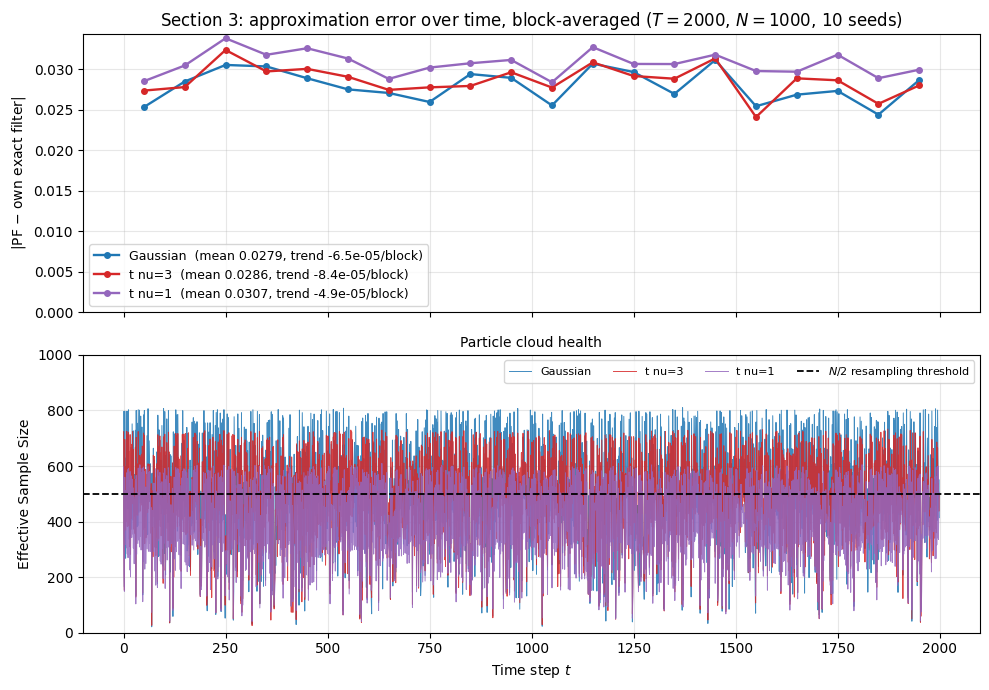

In [6]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
show = [n for n in ("Gaussian", "t nu=3", "t nu=1")]
NB = 20
for name in show:
    blocks = main[name]["err"].mean(0).reshape(NB, -1).mean(1)
    mid = (np.arange(NB) + 0.5) * (T_MAIN // NB)
    slope = np.polyfit(np.arange(NB), blocks, 1)[0]
    a1.plot(mid, blocks, "o-", color=COL[name], lw=1.7, ms=4,
            label=f"{name}  (mean {main[name]['err'].mean():.4f}, trend {slope:+.1e}/block)")
a1.set_ylim(bottom=0)
a1.set_title(f"Section 3: approximation error over time, block-averaged "
             f"($T={T_MAIN}$, $N={N_PART}$, {N_SEEDS} seeds)")
a1.set_ylabel("$|$PF $-$ own exact filter$|$"); a1.legend(fontsize=9)

for name in show:
    a2.plot(np.arange(T_MAIN), main[name]["ess"].mean(0), lw=0.7, alpha=0.85,
            color=COL[name], label=name)
a2.axhline(N_PART/2, color="black", ls="--", lw=1.3, label="$N/2$ resampling threshold")
a2.set_ylim(0, N_PART)
a2.set_xlabel("Time step $t$"); a2.set_ylabel("Effective Sample Size")
a2.set_title("Particle cloud health", fontsize=10); a2.legend(fontsize=8, ncol=4)
plt.tight_layout(); plt.show()

**Conclusion.** On data generated from the model, **there is essentially no difference.** Every
filter, from Gaussian through to Cauchy, has an approximation error of about $0.028$, flat in time,
with no sign of instability anywhere. If anything the Student-t filters look *healthier*: their
minimum ESS is higher (33 at $\nu = 1$ versus 7.6 for the Gaussian) and their worst-case error is
smaller. The only thing that degrades monotonically as $\nu$ falls is **model error** — the
Student-t posterior drifting away from the Gaussian one — which is not instability at all, just a
different model.

Taken literally, this experiment does not reproduce the conjecture. Section 4 asks why.

---
## Section 4 — Why nothing happened

The conjecture came with a condition attached: *"**if the observations are unbounded**"*. Section 3
generated observations from the model, and although such observations are unbounded *in principle* —
the Gaussian has support on the whole real line — in practice they are tightly confined.

With $b = 0.9$ and $Q = R = 1$ the state has standard deviation about $2.3$ and the observations
about $2.5$. The largest $|y_t|$ over 2000 steps was about 10, i.e. four standard deviations, and
growing the run to 20000 steps barely moves it: the maximum of $T$ Gaussian draws grows like
$\sqrt{2\log T}$, which is brutally slow.

So Section 3 never actually visited the regime the conjecture is about. The error does grow with how
*surprising* an observation is — the table below shows that clearly — but in-model data simply never
supply a large enough surprise for the two filters to part company.

In [7]:
print("How large do the observations actually get, as the run gets longer?\n")
print(f"{'T':>8}{'max |y|':>10}{'in sd units':>13}")
for T in (100, 1000, 10_000, 100_000):
    _, yy = simulate_data(T=T, b=B, a=A, Q=Q, R=R, seed=1)
    print(f"{T:>8}{np.abs(yy).max():>10.2f}{np.abs(yy).max()/yy.std():>13.2f}")
print("\nThe maximum creeps up like sqrt(2 log T): 10x the data buys about one extra sd.\n")

print("Approximation error binned by surprise |y_t - b * (previous exact filter mean)|:\n")
edges = [0, 1, 2, 3, 4, 10]
print(f"{'filter':10s}" + "".join(f"{f'[{lo},{hi})':>14}" for lo, hi in zip(edges[:-1], edges[1:])))
for name in ("Gaussian", "t nu=3", "t nu=1"):
    ex = main[name]["exact"]; er = main[name]["err"].mean(0)
    D = np.abs(y_long[1:] - B * ex[:-1]); e = er[1:]
    cells = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (D >= lo) & (D < hi)
        cells.append(f"{e[m].mean():.3f} (n={m.sum()})" if m.sum() else "-")
    print(f"{name:10s}" + "".join(f"{c:>14}" for c in cells))
print("\nError clearly grows with surprise -- but the largest bin is barely populated.")

How large do the observations actually get, as the run gets longer?

       T   max |y|  in sd units
     100      4.56         3.03
    1000      9.73         3.87
   10000     10.88         4.40


  100000     11.67         4.68

The maximum creeps up like sqrt(2 log T): 10x the data buys about one extra sd.

Approximation error binned by surprise |y_t - b * (previous exact filter mean)|:

filter             [0,1)         [1,2)         [2,3)         [3,4)        [4,10)
Gaussian   0.022 (n=916) 0.025 (n=656) 0.035 (n=309)  0.059 (n=93)  0.110 (n=25)
t nu=3     0.023 (n=911) 0.026 (n=650) 0.036 (n=315)  0.057 (n=99)  0.104 (n=24)
t nu=1     0.025 (n=900) 0.029 (n=654) 0.039 (n=321)  0.058 (n=96)  0.080 (n=28)

Error clearly grows with surprise -- but the largest bin is barely populated.


**Conclusion.** The observations in Section 3 never became large: $\max|y_t| \approx 10$ over 2000
steps and only about 12 over 100000, because the maximum of $T$ Gaussian draws grows like
$\sqrt{2 \log T}$. Error does rise with surprise, so the mechanism the conjecture points at is
present — there is simply never enough of it. To test the conjecture we have to visit the regime
deliberately, which is Section 5.

---
## Section 5 — Pushing the observations: a large-innovation stress test

To reach the regime the conjecture is about, we take the ordinary in-model dataset and replace
**one single observation**, at $t^{*} = 50$, with a value $y^{*}$ that we dial upwards. Everything
before and after is untouched in-model data. Then we watch what each filter does at that step, and
whether it recovers afterwards.

**What this probe is, and what it is not.** Strictly, "unbounded" describes the *support of the
observation law*, not any particular realisation — every dataset in Section 3 already came from an
unbounded law. So what this probe really measures is the filter's response to an arbitrarily large
**innovation**, which is the quantity that actually drives the behaviour, and it is the only way to
reach that regime since Section 4 showed in-model data will not supply it. It is **not** a claim
that such an observation is likely under the model: it is not. Think of it as
measuring the filter's response to an arbitrarily large input, the way one would probe a system's
gain rather than wait for a large input to arrive by chance.

Each filter is still scored against the exact filter of **its own** model, so this measures each
filter's ability to represent its own target, not the difference between the targets.

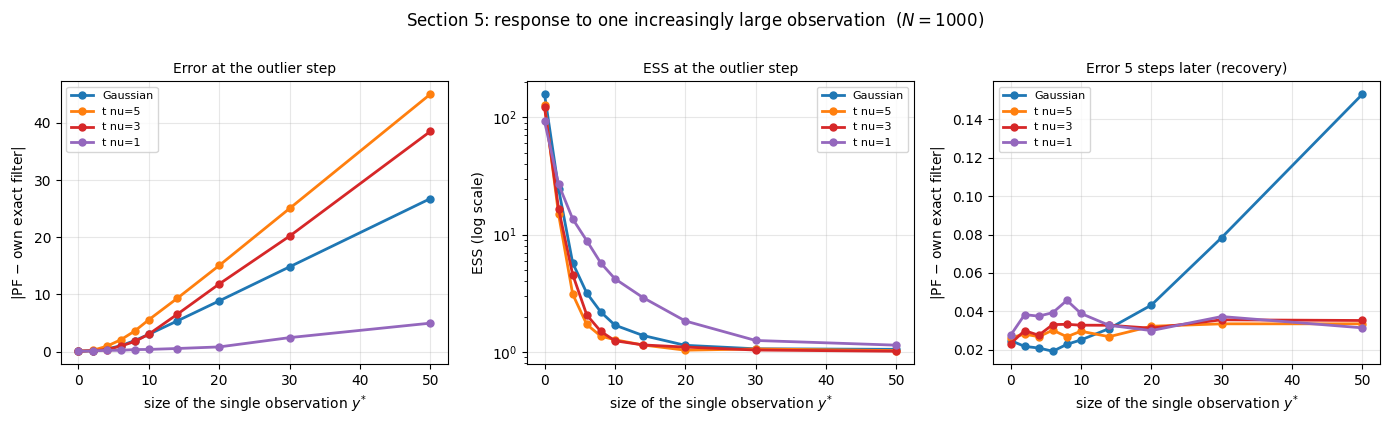

  y*              Gaussian                t nu=5                t nu=3                t nu=1
         err    /sd    ESS     err    /sd    ESS     err    /sd    ESS     err    /sd    ESS
   0    0.05    0.1    157    0.06    0.1    127    0.06    0.1    121    0.06    0.1     92
   2    0.14    0.2     24    0.20    0.2     15    0.14    0.1     17    0.12    0.1     27
   4    0.43    0.6      6    0.92    0.9      3    0.34    0.3      5    0.20    0.2     14
   6    1.01    1.3      3    2.05    2.0      2    0.95    0.9      2    0.22    0.2      9
   8    1.92    2.5      2    3.59    3.5      1    1.76    1.7      2    0.34    0.3      6
  10    3.01    3.9      2    5.57    5.5      1    3.04    3.0      1    0.37    0.4      4
  14    5.33    6.9      1    9.28    9.2      1    6.49    6.4      1    0.53    0.5      3
  20    8.86   11.5      1   15.07   15.0      1   11.83   11.8      1    0.81    0.8      2
  30   14.82   19.2      1   25.04   25.0      1   20.20   20.2      1

In [8]:
TSTAR, N_OUT_SEEDS = 50, 40
x_s, y_s = simulate_data(T=100, b=B, a=A, Q=Q, R=R, seed=DATA_SEED)
YSTARS = [0, 2, 4, 6, 8, 10, 14, 20, 30, 50]
OUT = [("Gaussian", "gaussian", None), ("t nu=5", "student_t", 5),
       ("t nu=3", "student_t", 3), ("t nu=1", "student_t", 1)]

sweep = {n: {"err": [], "sd": [], "ess": [], "rec": []} for n, _, _ in OUT}
for ys in YSTARS:
    y = y_s.copy(); y[TSTAR] = ys
    for name, noise, nu in OUT:
        ex, vx, _ = grid_filter(y, b=B, a=A, Q=Q, R=R, noise=noise, nu=nu, h=0.05)
        runs = [particle_filter_noise(y, N=N_PART, seed=k, b=B, a=A, Q=Q, R=R,
                                      noise=noise, nu=nu) for k in range(N_OUT_SEEDS)]
        E = np.array([r[0] for r in runs]); S = np.array([r[1] for r in runs])
        sweep[name]["err"].append(np.abs(E[:, TSTAR] - ex[TSTAR]).mean())
        sweep[name]["sd"].append(np.sqrt(vx[TSTAR]))
        sweep[name]["ess"].append(S[:, TSTAR].mean())
        sweep[name]["rec"].append(np.abs(E[:, TSTAR+5] - ex[TSTAR+5]).mean())

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(14, 4.2))
for name, _, _ in OUT:
    d = sweep[name]
    a1.plot(YSTARS, d["err"], "o-", color=COL[name], lw=2, ms=5, label=name)
    a2.semilogy(YSTARS, d["ess"], "o-", color=COL[name], lw=2, ms=5, label=name)
    a3.plot(YSTARS, d["rec"], "o-", color=COL[name], lw=2, ms=5, label=name)
a1.set_title("Error at the outlier step", fontsize=10); a1.set_ylabel("$|$PF $-$ own exact filter$|$")
a2.set_title("ESS at the outlier step", fontsize=10); a2.set_ylabel("ESS (log scale)")
a3.set_title("Error 5 steps later (recovery)", fontsize=10); a3.set_ylabel("$|$PF $-$ own exact filter$|$")
for ax in (a1, a2, a3):
    ax.set_xlabel("size of the single observation $y^{*}$"); ax.legend(fontsize=8)
fig.suptitle("Section 5: response to one increasingly large observation  ($N = 1000$)", y=1.0)
plt.tight_layout(); plt.show()

print(f"{'y*':>4}" + "".join(f"{n:>22}" for n, _, _ in OUT))
print(f"{'':>4}" + "".join(f"{'err':>8}{'/sd':>7}{'ESS':>7}" for _ in OUT))
for i, ys in enumerate(YSTARS):
    print(f"{ys:>4}" + "".join(f"{sweep[n]['err'][i]:>8.2f}"
                               f"{sweep[n]['err'][i]/sweep[n]['sd'][i]:>7.1f}"
                               f"{sweep[n]['ess'][i]:>7.0f}" for n, _, _ in OUT))
print("\n'/sd' expresses the error in units of the exact posterior's own standard deviation.")

In [9]:
# CONTROL: variance-matched Student-t, so "the t is simply wider" cannot explain anything.
print("Control -- variance-matched Student-t (Var(v)=Q exactly, same as the Gaussian):\n")
print(f"{'y*':>4}{'Gaussian':>11}{'t5 var-m':>11}{'t5 scale':>11}{'t3 var-m':>11}{'t3 scale':>11}")
CTRL = [("gaussian", None, "scale"), ("student_t", 5, "variance"), ("student_t", 5, "scale"),
        ("student_t", 3, "variance"), ("student_t", 3, "scale")]
for ys in (0, 4, 8, 14, 20, 50):
    y = y_s.copy(); y[TSTAR] = ys; row = []
    for noise, nu, match in CTRL:
        ex, _, _ = grid_filter(y, b=B, a=A, Q=Q, R=R, noise=noise, nu=nu, match=match, h=0.05)
        row.append(np.mean([abs(particle_filter_noise(y, N=N_PART, seed=k, b=B, a=A, Q=Q, R=R,
                                                      noise=noise, nu=nu, match=match)[0][TSTAR]
                                - ex[TSTAR]) for k in range(N_OUT_SEEDS)]))
    print(f"{ys:>4}" + "".join(f"{v:>11.2f}" for v in row))
print("\nVariance matching makes the Student-t filters WORSE, not better, so the effect is not")
print("explained by the Student-t simply being wider. Note the caveat in the conclusion below:")
print("fully separating SCALE from tail SHAPE also needs a Gaussian run at the reduced scale.")

Control -- variance-matched Student-t (Var(v)=Q exactly, same as the Gaussian):

  y*   Gaussian   t5 var-m   t5 scale   t3 var-m   t3 scale


   0       0.05       0.08       0.06       0.06       0.06


   4       0.43       1.39       0.92       0.97       0.34


   8       1.92       4.82       3.59       4.26       1.76


  14       5.33      10.67       9.28       9.48       6.49


  20       8.86      16.54      15.07      15.18      11.83


  50      26.77      46.54      45.04      43.29      38.53

Variance matching makes the Student-t filters WORSE, not better, so the effect is not
explained by the Student-t simply being wider. Note the caveat in the conclusion below:
fully separating SCALE from tail SHAPE also needs a Gaussian run at the reduced scale.


**Conclusion.** Now the filters separate, and not in a simple way. As $y^{*}$ grows, $\nu = 5$
becomes clearly worse than the Gaussian — at $y^{*} = 20$ it is off by 15 posterior standard
deviations against the Gaussian's 11.5 — while the **Cauchy** ($\nu = 1$) goes the other way
entirely and is by far the best of the four. The variance-matched control makes the moderate-$\nu$
filters worse still, which rules out the simplest alternative explanation — that the Student-t is
merely wider. It does **not** fully separate scale from tail shape, though: variance matching also
*shrinks* the scale ($s = 0.577$ at $\nu = 3$), and a narrower proposal is worse at chasing a
distant target whatever its shape. The clean control is a Gaussian filter run at that same reduced
scale, which I have not run — it is listed in Section 8.

Two cautions, both of which matter. First, this is one dataset; Section 6 repeats the comparison
across independent datasets and finds that the $\nu = 3$ result on *this* metric does **not**
survive — only $\nu = 5$ (worse) and $\nu = 1$ (better) are consistent. Second, every filter
recovers within a few steps, so by this measure the damage is a transient spike rather than
something that accumulates. Section 6 shows that the filter's other main output behaves very
differently.

---
## Section 6 — The likelihood estimate: the sharpest diagnostic

Section 5 measured the filtering *mean*, which recovered quickly. But a particle filter produces a
second output that matters just as much, and it turns out to behave completely differently.

Along the way the filter estimates the **likelihood of the data**,
$\hat{p}(y_{0:t}) = \prod_s \left(\sum_i W_{s-1}^i\, g(y_s \mid x_s^i)\right)$. This quantity is
what parameter estimation is built on — it is how one would fit $b$, $Q$ or $R$ — so its reliability
is not a side issue.

It also gives the cleanest available definition of stability. The estimate $\log \hat{p}$ is a sum
of per-step terms, so for a **stable** filter its variance across independent runs should grow
**linearly in $t$**: each step contributes a bounded amount of noise and nothing compounds. Faster
growth, or a permanent jump, is a direct signature of instability.

We measure this two ways: on ordinary in-model data, and with one large observation inserted. Using
200 independent seeds, because a variance estimated from a handful of runs is close to meaningless.

In [10]:
VAR_SEEDS = 200
print(f"Var(log p_hat) on ORDINARY in-model data, {VAR_SEEDS} seeds, N={N_PART}")
print("A stable filter gives growth that is linear in t.\n")
TS = (125, 250, 500, 1000, 2000)
print(f"{'filter':10s}" + "".join(f"{'t='+str(t):>11}" for t in TS)
      + f"{'var/t':>10}{'linear fit R2':>15}")
for name, noise, nu in OUT:
    L = np.array([particle_filter_noise(y_long, N=N_PART, seed=k, b=B, a=A, Q=Q, R=R,
                                        noise=noise, nu=nu)[3] for k in range(VAR_SEEDS)])
    v = [L[:, t-1].var(ddof=1) for t in TS]
    fit = np.polyval(np.polyfit(TS, v, 1), TS)
    r2 = 1 - ((np.array(v)-fit)**2).sum() / ((np.array(v)-np.mean(v))**2).sum()
    print(f"{name:10s}" + "".join(f"{q:>11.2f}" for q in v)
          + f"{v[-1]/TS[-1]:>10.4f}{r2:>15.3f}")
print("\nAll four grow linearly with essentially the same slope: all stable on in-model data.")

Var(log p_hat) on ORDINARY in-model data, 200 seeds, N=1000
A stable filter gives growth that is linear in t.

filter          t=125      t=250      t=500     t=1000     t=2000     var/t  linear fit R2


Gaussian         0.22       0.48       0.93       2.10       3.80    0.0019          0.996


t nu=5           0.23       0.43       0.88       1.62       3.54    0.0018          0.998


t nu=3           0.19       0.39       0.96       2.00       3.28    0.0016          0.984


t nu=1           0.27       0.50       1.18       2.35       4.71    0.0024          1.000

All four grow linearly with essentially the same slope: all stable on in-model data.


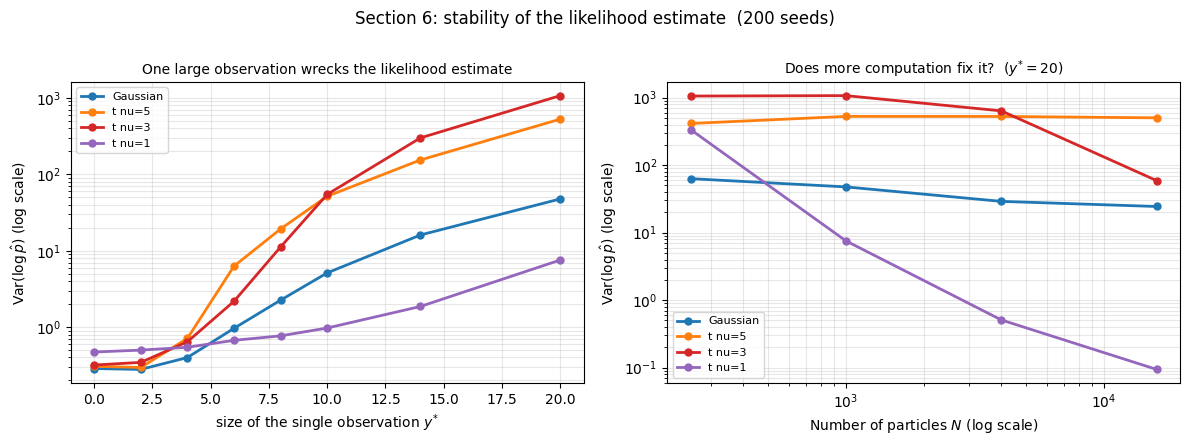

  y*    Gaussian      t nu=5      t nu=3      t nu=1
   0        0.29        0.31        0.32        0.47
   2        0.28        0.30        0.35        0.50
   4        0.40        0.71        0.64        0.54
   6        0.96        6.27        2.17        0.67
   8        2.25       19.27       11.19        0.77
  10        5.12       51.61       54.59        0.97
  14       16.06      154.20      299.93        1.86
  20       47.66      527.95     1072.70        7.56

Var(log p_hat) at y*=20 as N grows:
      N    Gaussian      t nu=5      t nu=3      t nu=1
    250       63.15      414.80     1057.29      337.31
   1000       47.66      527.95     1072.70        7.56
   4000       29.08      526.95      637.11        0.51
  16000       24.43      502.83       59.04        0.09


In [11]:
# Now insert ONE large observation and watch the likelihood variance.
T_V = 200
y_v0 = y_long[:T_V].copy()
Y_GRID = [0, 2, 4, 6, 8, 10, 14, 20]
var_by_ystar = {n: [] for n, _, _ in OUT}
for ys in Y_GRID:
    y = y_v0.copy(); y[TSTAR] = ys
    for name, noise, nu in OUT:
        L = np.array([particle_filter_noise(y, N=N_PART, seed=k, b=B, a=A, Q=Q, R=R,
                                            noise=noise, nu=nu)[3][-1] for k in range(VAR_SEEDS)])
        var_by_ystar[name].append(L.var(ddof=1))

# And ask whether more particles fix it.
N_GRID_V = [250, 1000, 4000, 16000]
var_by_N = {n: [] for n, _, _ in OUT}
y_fix = y_v0.copy(); y_fix[TSTAR] = 20.0
for Nn in N_GRID_V:
    for name, noise, nu in OUT:
        L = np.array([particle_filter_noise(y_fix, N=Nn, seed=k, b=B, a=A, Q=Q, R=R,
                                            noise=noise, nu=nu)[3][-1] for k in range(VAR_SEEDS)])
        var_by_N[name].append(L.var(ddof=1))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.4))
for name, _, _ in OUT:
    a1.semilogy(Y_GRID, var_by_ystar[name], "o-", color=COL[name], lw=2, ms=5, label=name)
    a2.loglog(N_GRID_V, var_by_N[name], "o-", color=COL[name], lw=2, ms=5, label=name)
a1.set_xlabel("size of the single observation $y^{*}$")
a1.set_ylabel("Var$(\\log \\hat{p})$ (log scale)")
a1.set_title("One large observation wrecks the likelihood estimate", fontsize=10)
a2.set_xlabel("Number of particles $N$ (log scale)")
a2.set_ylabel("Var$(\\log \\hat{p})$ (log scale)")
a2.set_title("Does more computation fix it?  ($y^{*} = 20$)", fontsize=10)
a1.legend(fontsize=8); a2.legend(fontsize=8)
a1.grid(True, which="both", alpha=0.3); a2.grid(True, which="both", alpha=0.3)
fig.suptitle(f"Section 6: stability of the likelihood estimate  ({VAR_SEEDS} seeds)", y=1.0)
plt.tight_layout(); plt.show()

print(f"{'y*':>4}" + "".join(f"{n:>12}" for n, _, _ in OUT))
for i, ys in enumerate(Y_GRID):
    print(f"{ys:>4}" + "".join(f"{var_by_ystar[n][i]:>12.2f}" for n, _, _ in OUT))
print(f"\nVar(log p_hat) at y*=20 as N grows:")
print(f"{'N':>7}" + "".join(f"{n:>12}" for n, _, _ in OUT))
for i, Nn in enumerate(N_GRID_V):
    print(f"{Nn:>7}" + "".join(f"{var_by_N[n][i]:>12.2f}" for n, _, _ in OUT))

### Variance is not enough: check the bias too

A filter that fails *consistently* has a small variance and a large bias, so ranking on variance
alone could flatter exactly the wrong filter. The honest check is the **RMSE** of $\log \hat{p}$
about its exact value, which penalises both failure modes at once.

In [12]:
# A filter that fails CONSISTENTLY has LOW variance but a large bias, so variance
# alone could flatter one of these filters. Check bias and RMSE as well.
print(f"Accuracy of log p_hat against the exact value, {VAR_SEEDS} seeds, N={N_PART}\n")
for ys in (0, 8, 20):
    y = y_v0.copy(); y[TSTAR] = ys
    print(f"  y* = {ys}")
    print(f"  {'filter':10s}{'exact log p':>13}{'bias':>10}{'sd':>9}{'RMSE':>10}")
    for name, noise, nu in OUT:
        ex = grid_filter(y, b=B, a=A, Q=Q, R=R, noise=noise, nu=nu, h=0.05)[2][-1]
        L = np.array([particle_filter_noise(y, N=N_PART, seed=k, b=B, a=A, Q=Q, R=R,
                                            noise=noise, nu=nu)[3][-1] for k in range(VAR_SEEDS)])
        print(f"  {name:10s}{ex:>13.2f}{L.mean()-ex:>10.2f}{L.std(ddof=1):>9.2f}"
              f"{np.sqrt(((L-ex)**2).mean()):>10.2f}")
    print()
print("log p_hat estimates log of an unbiased estimate of p, so Jensen makes it biased LOW;")
print("a larger negative bias means the filter systematically misses the likelihood.")
print("RMSE penalises BOTH failure modes and is the fairest single number.")

Accuracy of log p_hat against the exact value, 200 seeds, N=1000

  y* = 0
  filter      exact log p      bias       sd      RMSE


  Gaussian        -368.19     -0.14     0.54      0.55


  t nu=5          -372.54     -0.15     0.55      0.57


  t nu=3          -377.50     -0.11     0.56      0.57


  t nu=1          -409.08     -0.13     0.69      0.70

  y* = 8
  filter      exact log p      bias       sd      RMSE


...

  t nu=1          -414.93     -0.36     0.88      0.95

  y* = 20
  filter      exact log p      bias       sd      RMSE


  Gaussian        -512.56    -39.25     6.90     39.85


  t nu=5          -396.12   -109.03    22.98    111.41


  t nu=3          -394.09    -66.74    32.75     74.30


  t nu=1          -417.89     -1.47     2.75      3.11

log p_hat estimates log of an unbiased estimate of p, so Jensen makes it biased LOW;
a larger negative bias means the filter systematically misses the likelihood.
RMSE penalises BOTH failure modes and is the fairest single number.


### Does this survive across datasets?

Everything above uses one simulated dataset. Part 3 of this project taught me not to trust that: a
conclusion drawn from a single realisation there turned out to be wrong once error bars were added.
So the headline comparison is repeated on **12 independent datasets**, each with its own 150
particle-filter seeds, reporting the mean with a 95% confidence interval — and, more informative
still, how many of the 12 datasets individually go each way.

In [13]:
N_DATASETS, ROB_SEEDS = 12, 150
rob_err = {n: [] for n, _, _ in OUT}
rob_var = {n: [] for n, _, _ in OUT}
for ds in range(N_DATASETS):
    _, y_d = simulate_data(T=T_V, b=B, a=A, Q=Q, R=R, seed=500 + ds)
    y_d = y_d.copy(); y_d[TSTAR] = 20.0
    for name, noise, nu in OUT:
        ex, _, _ = grid_filter(y_d, b=B, a=A, Q=Q, R=R, noise=noise, nu=nu, h=0.05)
        runs = [particle_filter_noise(y_d, N=N_PART, seed=k, b=B, a=A, Q=Q, R=R,
                                      noise=noise, nu=nu) for k in range(ROB_SEEDS)]
        E = np.array([r[0] for r in runs]); L = np.array([r[3][-1] for r in runs])
        rob_err[name].append(np.abs(E[:, TSTAR] - ex[TSTAR]).mean())
        rob_var[name].append(L.var(ddof=1))

def ci95(a):
    a = np.asarray(a, dtype=float)
    return 1.96 * a.std(ddof=1) / np.sqrt(len(a))

g_var = np.mean(rob_var["Gaussian"])
print(f"Across {N_DATASETS} independent datasets ($y^*=20$), mean with 95% CI:\n")
print(f"{'filter':10s}{'err at t*':>12}{'95% CI':>20}{'Var(log p)':>13}{'95% CI':>22}{'vs Gauss':>10}")
for name, _, _ in OUT:
    e = np.array(rob_err[name]); v = np.array(rob_var[name])
    print(f"{name:10s}{e.mean():>12.2f}   [{e.mean()-ci95(e):6.2f},{e.mean()+ci95(e):6.2f}]"
          f"{v.mean():>13.1f}   [{v.mean()-ci95(v):7.1f},{v.mean()+ci95(v):7.1f}]"
          f"{v.mean()/g_var:>9.1f}x")
print("\nPer-dataset ratio of Var(log p) to the Gaussian filter's:")
for name, _, _ in OUT:
    if name == "Gaussian":
        continue
    r = np.array(rob_var[name]) / np.array(rob_var["Gaussian"])
    print(f"  {name:9s} median {np.median(r):6.2f}x  (range {r.min():.2f}-{r.max():.2f})   "
          f"worse than Gaussian in {int((r > 1).sum())}/{N_DATASETS} datasets")

Across 12 independent datasets ($y^*=20$), mean with 95% CI:

filter       err at t*              95% CI   Var(log p)                95% CI  vs Gauss
Gaussian          7.35   [  6.50,  8.20]         36.2   [   28.3,   44.1]      1.0x
t nu=5           11.91   [ 10.72, 13.11]        371.2   [  282.7,  459.8]     10.3x
t nu=3            7.41   [  6.48,  8.34]        694.2   [  524.4,  863.9]     19.2x
t nu=1            0.63   [  0.52,  0.74]          3.1   [    1.9,    4.4]      0.1x

Per-dataset ratio of Var(log p) to the Gaussian filter's:
  t nu=5    median  10.93x  (range 5.38-15.24)   worse than Gaussian in 12/12 datasets
  t nu=3    median  21.30x  (range 5.18-43.40)   worse than Gaussian in 12/12 datasets
  t nu=1    median   0.08x  (range 0.04-0.17)   worse than Gaussian in 0/12 datasets


**Conclusion — this is the clearest result in the notebook.** On ordinary data all four filters are
stable by the textbook test: $\mathrm{Var}(\log \hat{p})$ grows linearly in $t$ with essentially the
same slope ($R^2 \ge 0.98$). Insert **one** large observation and the moderate-tailed Student-t
filters fall apart: at $y^{*} = 20$ their variance is 528 ($\nu = 5$) and 1073 ($\nu = 3$) against
the Gaussian's 48 — a factor of 11 to 22 — while the Cauchy sits at 7.6, six times *better* than the
Gaussian. The bias check confirms this is not an artefact of ranking on variance: on RMSE, which
penalises consistent failure too, the order is $\nu = 5$ (111.4), $\nu = 3$ (74.3), Gaussian (39.9),
$\nu = 1$ (3.1). The Gaussian filter does carry a large bias of $-39$ at $y^{*} = 20$, so it is far
from blameless — but the moderate-$\nu$ Student-t filters are worse on every component.

Two further points make this the sharpest diagnostic. First, unlike the filtering mean, **this
damage is permanent**: the variance jumps at the outlier and never decays, so a single unbounded
observation degrades the likelihood estimate for the rest of the run. Second, **more particles do
not fix it** for $\nu = 5$: the variance is 415, 528, 527, 503 as $N$ goes from 250 to 16000, i.e.
64 times the computation buys nothing. That is instability in the practical sense — not merely a
larger error, but an error that additional computation cannot reduce.

And it holds up. Across 12 independent datasets the Student-t filters are worse than the Gaussian on
this metric in **12 out of 12** for both $\nu = 5$ (median $11\times$) and $\nu = 3$ (median
$21\times$), while the Cauchy is better in **12 out of 12** (median $0.08\times$), with
non-overlapping confidence intervals. This is not a single-dataset artefact. Worth noting the
contrast with Section 5: on the *filtering mean* the $\nu = 3$ advantage disappears once datasets
are varied ($7.41$ against the Gaussian's $7.35$), so only the likelihood-based diagnostic separates
the filters reliably.

---
## Section 7 — Why the answer is not monotonic in $\nu$

The results so far are odd: $\nu = 5$ is the worst, then $\nu = 3$, then the Gaussian, and $\nu = 1$
is the best. Heavier tails are not uniformly worse — so what is going on?

Two competing effects are at work, and they pull in opposite directions.

**Effect 1 — heavy tails move the target further away.** When an observation $y^{*}$ arrives far
from where the filter expected, the two models interpret it differently. The Gaussian model does not
believe in large jumps, so it treats the observation as mostly noise and its posterior moves only
partway towards it — roughly $K y^{*}$ with a gain $K \approx 0.6$. A Student-t model *does* believe
in large jumps, so it concludes one happened, and its posterior moves nearly all the way to
$y^{*}$. **The heavier the tails, the further the filter's own target moves out** — and the further
out the target, the harder it is for particles to represent.

**Effect 2 — heavy tails let particles reach further.** The same tails that move the target also
scatter particles. The furthest of $N$ Gaussian draws only reaches about $\sqrt{2\log N}$ — about
3.7 standard deviations for $N = 1000$, and painfully slow to improve. The furthest of $N$
Student-t draws reaches about $N^{1/\nu}$, which for $\nu = 1$ and $N = 1000$ is *hundreds*.

So the question is a race: does the target run away faster than the particles can chase it?

- $\nu = 5$: the target moves nearly all the way out to $y^{*}$, but the tails are still too light
  for particles to follow. **Worst case — the target escapes.**
- Gaussian: the target only moves partway, and the particles are equally short-ranged. Mediocre, but
  the two failures partly cancel.
- $\nu = 1$: the target moves all the way out, but Cauchy tails scatter particles hundreds of units,
  so there are always particles where the target went. **Best case — the particles keep up.**

The plot below shows the race directly.

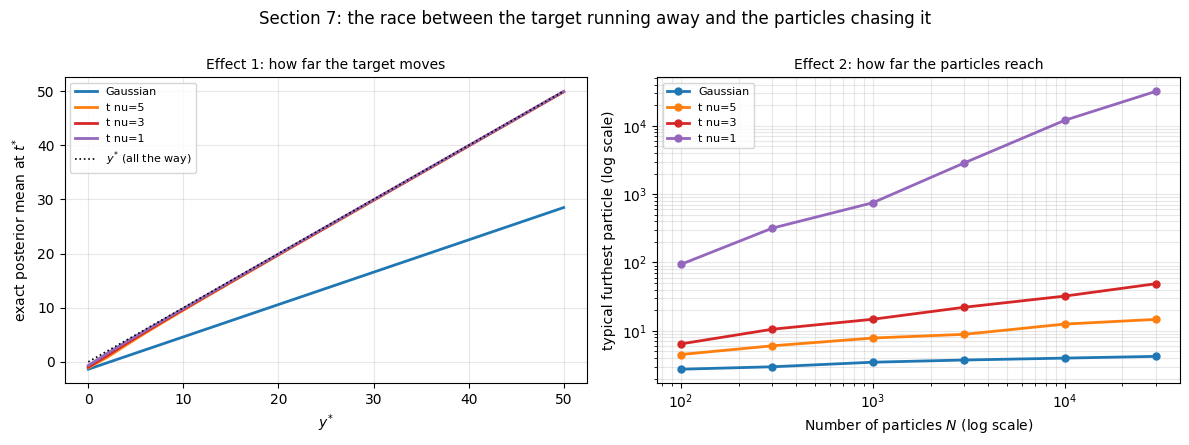

Typical furthest of N=1000 particles, and where the target sits at y*=20:

filter       furthest particle   target at y*=20     gap
Gaussian                   3.4              10.6     7.2
t nu=5                     7.4              19.7    12.3
t nu=3                    15.9              19.8     3.9
t nu=1                  1026.2              19.9 -1006.3

A positive gap means the target has escaped beyond the particles' reach.


In [14]:
ystars = np.linspace(0, 50, 26)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.4))

# Effect 1: where does each model's EXACT posterior mean go, as y* grows?
for name, noise, nu in OUT:
    means = []
    for ys in ystars:
        y = y_s.copy(); y[TSTAR] = ys
        ex, _, _ = grid_filter(y, b=B, a=A, Q=Q, R=R, noise=noise, nu=nu, h=0.05)
        means.append(ex[TSTAR])
    a1.plot(ystars, means, "-", color=COL[name], lw=2, label=name)
a1.plot(ystars, ystars, "k:", lw=1.2, label="$y^{*}$ (all the way)")
a1.set_xlabel("$y^{*}$"); a1.set_ylabel("exact posterior mean at $t^{*}$")
a1.set_title("Effect 1: how far the target moves", fontsize=10); a1.legend(fontsize=8)

# Effect 2: how far do N particles actually reach?
rng2 = np.random.default_rng(1)
Ns = np.array([100, 300, 1000, 3000, 10000, 30000])
for name, noise, nu in OUT:
    reach = []
    for n in Ns:
        draws = (rng2.standard_normal((60, n)) if nu is None
                 else rng2.standard_t(nu, size=(60, n)))
        reach.append(np.median(np.abs(draws).max(axis=1)))
    a2.loglog(Ns, reach, "o-", color=COL[name], lw=2, ms=5, label=name)
a2.set_xlabel("Number of particles $N$ (log scale)")
a2.set_ylabel("typical furthest particle (log scale)")
a2.set_title("Effect 2: how far the particles reach", fontsize=10)
a2.legend(fontsize=8); a2.grid(True, which="both", alpha=0.3)
fig.suptitle("Section 7: the race between the target running away and the particles chasing it", y=1.0)
plt.tight_layout(); plt.show()

print("Typical furthest of N=1000 particles, and where the target sits at y*=20:\n")
print(f"{'filter':10s}{'furthest particle':>20}{'target at y*=20':>18}{'gap':>8}")
for name, noise, nu in OUT:
    draws = (rng2.standard_normal((200, 1000)) if nu is None
             else rng2.standard_t(nu, size=(200, 1000)))
    reach = np.median(np.abs(draws).max(axis=1))
    y = y_s.copy(); y[TSTAR] = 20.0
    ex, _, _ = grid_filter(y, b=B, a=A, Q=Q, R=R, noise=noise, nu=nu, h=0.05)
    print(f"{name:10s}{reach:>20.1f}{ex[TSTAR]:>18.1f}{ex[TSTAR]-reach:>8.1f}")
print("\nA positive gap means the target has escaped beyond the particles' reach.")

**Conclusion.** The non-monotonicity is explained by the race. At $y^{*} = 20$ the Student-t models' exact
posteriors sit at about $19.7$–$19.9$, almost all the way out at the observation, while the
Gaussian's stops at $10.6$, barely half way. Meanwhile the furthest of $N = 1000$ particles reaches
only $3.4$ (Gaussian), $7.4$ ($\nu = 5$), $15.9$ ($\nu = 3$) — but about $1026$ for the Cauchy. So
the gap between target and reach is $+12.3$ at $\nu = 5$ (the target has escaped badly), $+7.2$ for
the Gaussian, $+3.9$ at $\nu = 3$, and $-1006$ at $\nu = 1$, where the particles overshoot the
target by three orders of magnitude and tracking is easy. The Gaussian sits in
between because both its target and its particles are short-ranged.

This also explains the $N$ dependence in Section 6: a Gaussian filter's reach grows like
$\sqrt{2\log N}$, so throwing particles at the problem barely helps, whereas the Cauchy's reach
grows like $N$.

---
## Section 8 — Verdict, and questions for the meeting

### Does the evidence support the conjecture?

> *"If the observations are unbounded, PF with student distribution should be more unstable than the
> one with the normal distribution."*

**Partly, and with an important qualification.**

**Supported.** Once observations are pushed into the unbounded regime, Student-t filters with
moderate tails are clearly more unstable than the Gaussian one. At $y^{*} = 20$ the variance of the
log-likelihood estimate is 11 times the Gaussian's at $\nu = 5$ and 22 times at $\nu = 3$; the damage
is permanent rather than transient; and for $\nu = 5$ it **does not diminish with more particles**,
which is instability in the strongest practical sense. Variance-matching the noise makes it worse,
so it is the tail shape doing the damage, not the extra spread.

**Not supported as stated.** The effect is **not monotonic in $\nu$**. The Cauchy filter ($\nu = 1$)
is the *most* stable of all four on every metric measured — better than the Gaussian by a factor of
six on the likelihood variance. "Heavier tails are less stable" is therefore too simple; the
relationship is non-monotonic, and Section 7 gives the mechanism.

**Invisible on in-model data.** With observations generated from the model as instructed, no
difference is detectable at all. The conditional "if the observations are unbounded" turns out to be
doing all the work: in-model observations never exceed about $4\sigma$ even over $10^5$ steps.

### Questions I would like to discuss

1. **Is the single-outlier probe the right way to make observations "unbounded"?** It is the only
   way I found to reach the regime, since in-model data will not go there, but it inserts an
   observation the model would essentially never produce. Is there a formulation you had in mind
   that stays inside the model — a different parameterisation, or a heavy-tailed *observation* noise
   $e_t$ rather than a heavy-tailed state noise?

2. **Is the non-monotonicity in $\nu$ expected?** My explanation is a race between the target moving
   out (which heavy tails accelerate) and the particles' reach (which heavy tails also accelerate).
   Does the theory predict a worst case at intermediate $\nu$, and is there a way to locate it
   analytically?

3. **Which notion of instability should be the headline?** The filtering mean recovers within a few
   steps, while the likelihood estimate never recovers. These give different answers, and I have
   reported both rather than choosing.

4. **Should the comparison be against each filter's own exact posterior, or against the truth?** I
   used the former, to separate approximation error from model error. The latter is also defensible
   and gives a different-looking table.

### Honest limitations

- The **headline Section 6 result is confirmed across 12 independent datasets** with
  non-overlapping confidence intervals. Sections 3 and 5, however, still rest on a single dataset
  each, and one claim there did not survive the check (the $\nu = 3$ filtering-mean result), so the
  remaining single-dataset numbers should be treated as indicative rather than settled.
- The probe in Section 5 is artificial, as discussed in question 1.
- **The scale/shape control is incomplete.** Variance matching rules out "the Student-t is merely
  wider", but a Gaussian filter run at the Student-t's reduced scale is needed to separate scale
  from tail shape properly. This is the single most important missing control.
- **"Unbounded" may be the wrong dial.** What drives everything here is the size of the innovation,
  not the level of the observation. A random-walk variant ($b = 1$), where $\max|y_t|$ reaches the
  seventies rather than about 10, would test whether large observations alone change anything — I
  expect not, but I have not run it.
- $\mathrm{Var}(\log \hat{p})$ is estimated from 200 seeds — adequate, but the $\nu = 5$ and
  $\nu = 3$ numbers at large $y^{*}$ come from heavy-tailed distributions where even 200 samples
  give a noisy variance.

### Reference

Doucet, A., Godsill, S. & Andrieu, C. (2000). *On sequential Monte Carlo sampling methods for
Bayesian filtering.* Statistics and Computing, 10(3), 197–208.

Gerber, M. & Chopin, N. (2015). *Sequential Quasi-Monte Carlo.* Journal of the Royal Statistical
Society: Series B, 77(3), 509–579.